READ ANALYSIS XLSX

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import os
%matplotlib inline
os.getcwd()
file = '../Scenario_Analysis.xlsx'
df = pd.read_excel(file, sheet_name='CO2Duals')
df = df.loc[:, ~df.columns.str.contains(r'\.\d+$')]
df = df.set_index(df.columns[0])
hours = df.index
start_date = pd.Timestamp("2019-01-01 00:00")
dt_index = start_date + pd.to_timedelta(hours-1, unit="h")
df.index = dt_index
df.index.name = "datetime"
df.index.freq = 'h'


PLOT HOURLY DUALS ALONG THEIR MOVING AVERAGE

In [23]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import NullLocator
import matplotlib.colors as mc
import colorsys

# helper function: darken a color nicely
def darken(color, amount=0.55):
    try:
        c = mc.cnames[color]
    except:
        c = color
    h, l, s = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(h, max(0, min(1, l * amount)), s)


def plot_scenarios(df, scenarios, scenario_colors, start=None, end=None, ma_window=168):

    data = df[scenarios]
    if start or end:
        data = data.loc[start:end]

    fig, ax = plt.subplots(figsize=(14, 5))

    for scen in scenarios:
        base_color = scenario_colors[scen]
        ma_color = darken(base_color, 0.8)

        # Hourly line (faint)
        ax.plot(
            data.index,
            data[scen],
            color=base_color,
            alpha=0.25,
            label=scen
        )

        # Weekly moving average (bold)
        ma = data[scen].rolling(window=ma_window, min_periods=1).mean()
        ax.plot(
            data.index,
            ma,
            color=ma_color,
            label=f"{ma_window}h MA ({scen})"
        )

    ax.set_xlabel("")
    ax.set_ylabel("CO₂ Dual (EUR/t)")
    ax.set_title("Hourly CO₂ Dual (EUR/t)")
    # after you compute `data`
    first = data.index.min().normalize().replace(day=1)
    last = data.index.max()
    last_month_start = last.normalize().replace(day=1)
    next_month_start = last_month_start + pd.offsets.MonthBegin(1)

    ax.set_xlim(first, next_month_start)
    ax.margins(x=0)  # still no extra padding beyond these limits
    ax.margins(x=0)

    # Monthly ticks
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.xaxis.set_minor_locator(NullLocator())

    ax.set_ylim(0, 120)

    ax.grid(axis='y', alpha=0.4)
    ax.set_axisbelow(True)

    
    # Legend below
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.12),
        ncol=len(scenarios) * 2,
        frameon=False,
    )

    fig.tight_layout()
    return fig


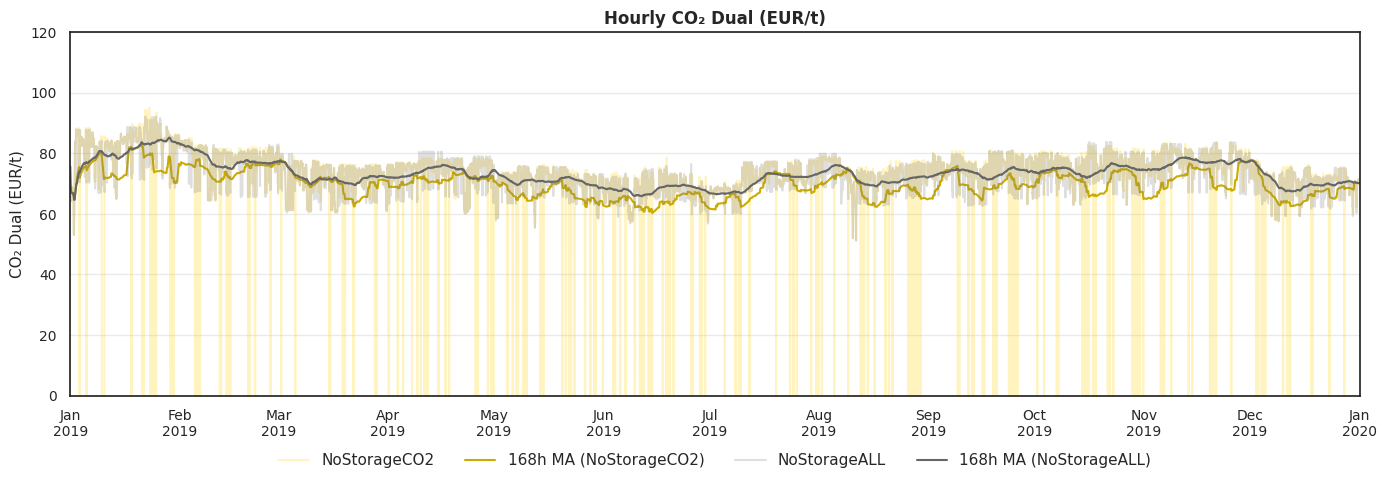

In [24]:
# all_colors 
# aqua, cyan, turquoise, teal, green, lime, forestgreen, chartreuse,
# blue, royalblue, deepskyblue, dodgerblue, skyblue, cornflowerblue,
# red, firebrick, crimson, orange, darkorange, gold, purple, indigo, magenta,
# brown, sienna, chocolate, gray, dimgray, slategray, black, white, lavenderblush

scenario_colors = {
    "Baseline":  "darkred",
    "NoStorageCO2": "gold",
    "NoStorageALL": "gray",
    "H2":        "dodgerblue",
    "BioFixed":  "green",
    "CO2Trans": "purple"
}

start="2019-01-01"
end="2020-01-01"

fig = plot_scenarios(df, ["NoStorageCO2", "NoStorageALL"], scenario_colors, start=start, end=end)

fig.savefig("DualCO2Hourly.pdf", format="pdf", bbox_inches="tight")
plt.show(fig)


PLOTTING ONLY MOVING AVERAGES (MAs)

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import NullLocator

def plot_ma_scenarios(df, scenarios, scenario_colors=None,
                      start=None, end=None, ma_window=168, min_per=1):
    """
    Plot only moving-average (MA) trends for selected scenarios.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame with datetime index and scenario columns.
    scenarios : list of str
        Column names (scenarios) to plot.
    scenario_colors : dict, optional
        Mapping {scenario_name: color_string}, e.g.
        {"Baseline": "royalblue", "BioFixed": "turquoise"}.
        If a scenario is not in the dict, Matplotlib's default color cycle is used.
    start, end : str or Timestamp, optional
        Optional time window, e.g. '2019-03-01', '2019-06-30'.
    ma_window : int
        Moving average window in hours (e.g. 168 = 1 week).
    min_per : int
        min_periods argument for rolling().
    """

    if scenario_colors is None:
        scenario_colors = {}

    data = df[scenarios]
    if start or end:
        data = data.loc[start:end]

    fig, ax = plt.subplots(figsize=(14, 5))

    for scen in scenarios:
        ma = data[scen].rolling(window=ma_window, min_periods=min_per).mean()

        color = scenario_colors.get(scen, None)  # None → default color cycle

        ax.plot(
            data.index,
            ma,
            linestyle="-",
            linewidth=2,
            label=f"{ma_window}h MA ({scen})",
            color=color,
        )

    ax.set_xlabel("")
    ax.set_ylabel("CO₂ Dual (EUR/t)")
    ax.set_title(f"{ma_window}-hour Moving Average CO₂ Dual")

    # --- Month-aligned x-limits (so you get Jan 2020 when plotting full 2019) ---
    first_month_start = data.index.min().normalize().replace(day=1)
    last_month_start = data.index.max().normalize().replace(day=1)
    next_month_start = last_month_start + pd.offsets.MonthBegin(1)

    ax.set_xlim(first_month_start, next_month_start)
    ax.margins(x=0)

    # Monthly ticks only
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.xaxis.set_minor_locator(NullLocator())

    ax.grid(axis='y', alpha=0.4)
    ax.set_axisbelow(True)


    # Legend below
    legend = ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.12),
        ncol=len(scenarios),
        frameon=False
    )
    for line in legend.get_lines():
        line.set_linewidth(3)

    fig.tight_layout()
    return fig


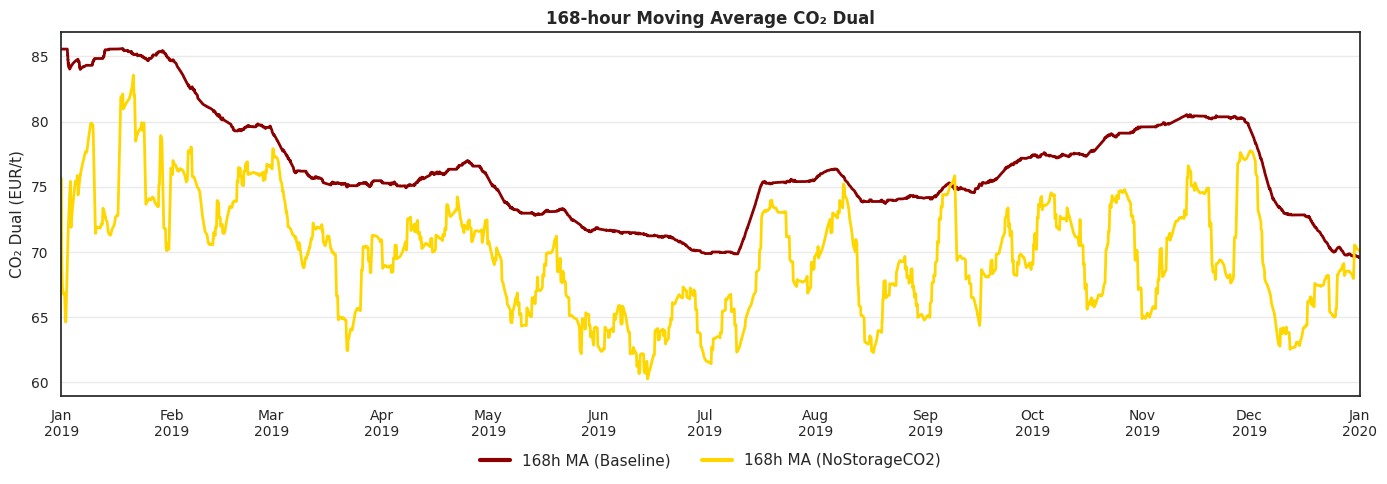

In [26]:
scenario_colors = {
    "Baseline":  "darkred",
    "NoStorageCO2": "gold",
    "NoStorageALL": "gray",
    "H2":        "dodgerblue",
    "BioFixed":  "green",
    "CO2Trans": "purple"
}
start="2019-01-01"
end="2020-01-01"

fig = plot_ma_scenarios(
    df,
    ["Baseline", "NoStorageCO2"],
    scenario_colors=scenario_colors,
    start=start,
    end=end,
    ma_window=168,
)

fig.savefig("DualCO2MA.pdf", format="pdf", bbox_inches="tight")
plt.show()

AVERAGE CO2 DUAL VALUE

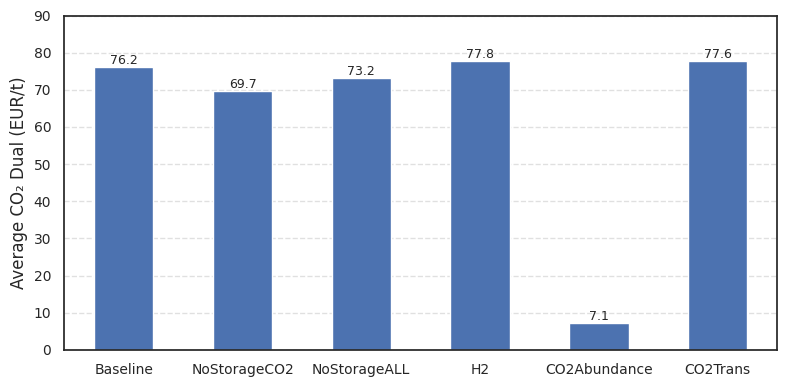

In [27]:
import matplotlib.pyplot as plt

scenario_means = df.mean()

fig, ax = plt.subplots(figsize=(8,4))

scenario_means.plot(kind='bar', ax=ax)

ax.set_ylabel("Average CO₂ Dual (EUR/t)", fontsize=12)
# ax.set_title("Average CO₂ Dual Value per Scenario")

# Grid behind bars
ax.grid(axis='y', alpha=0.6, linestyle='--')
ax.set_axisbelow(True)

# X and Y ticks
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')

max_val = int(scenario_means.max())
tick_step = 10  # same spacing as before

ax.set_yticks(range(0, max_val + 2*tick_step, tick_step))
ax.set_ylim(0, 90)

for i, value in enumerate(scenario_means):
    ax.text(
        i,                         # x-position
        value,                # y-position slightly above bar
        f"{value:.1f}",           # formatted label
        ha='center', va='bottom', fontsize=9
    )

plt.tight_layout()
plt.savefig("DualCO2Average.pdf", format="pdf", bbox_inches="tight")
plt.show()


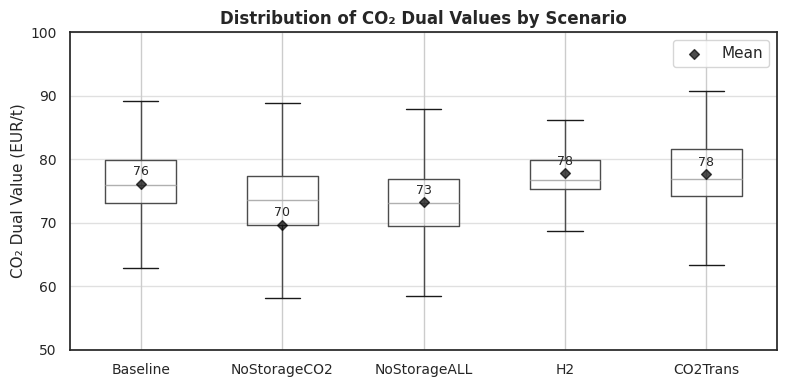

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# --- Select scenarios ---
scenarios = [
    "Baseline",
    "NoStorageCO2",
    "NoStorageALL",
    "H2",
    # "BioFixed",
    "CO2Trans"
]

fig, ax = plt.subplots(figsize=(8,4))  # same size as methanol

# --- Boxplot ---
df[scenarios].boxplot(
    ax=ax,
    showfliers=False
)

# --- Compute means ---
means = df[scenarios].mean()
x_positions = np.arange(1, len(means) + 1)

# --- Mean markers (same style as methanol) ---
ax.scatter(
    x_positions,
    means,
    marker="D",
    s=25,              # smaller size (same as methanol)
    color="black",
    alpha=0.7,
    label="Mean",
    zorder=3
)

# --- Mean value labels (same style as methanol) ---
for x, mean in zip(x_positions, means):
    ax.annotate(
        f"{mean:.0f}",
        (x, mean),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=9
    )

# --- Labels & styling (aligned with methanol plot) ---
ax.set_ylabel("CO₂ Dual Value (EUR/t)")
ax.set_title("Distribution of CO₂ Dual Values by Scenario")

ax.grid(axis="y", alpha=0.6)
ax.set_axisbelow(True)

ax.set_ylim(50, 100)

plt.xticks(rotation=0)
ax.legend()

plt.tight_layout()
plt.savefig("DualCO2_Boxplot_AllScenarios.pdf", bbox_inches="tight")
plt.show()


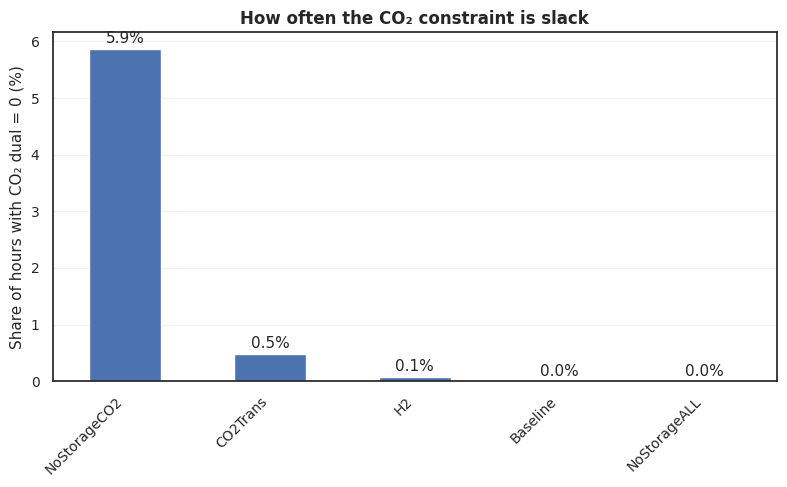

In [29]:
import matplotlib.pyplot as plt

# choose scenarios
scenarios = [
    "Baseline",
    "NoStorageCO2",
    "NoStorageALL",
    "H2",
    "CO2Trans"
]

# compute share of zero hours (%)
zero_share = (df[scenarios] == 0).mean() * 100
zero_share = zero_share.sort_values(ascending=False)

# plot
fig, ax = plt.subplots(figsize=(8,5))

zero_share.plot(kind="bar", ax=ax)

for i, v in enumerate(zero_share):
    ax.text(i, v + 0.1, f"{v:.1f}%", ha="center")

ax.set_ylabel("Share of hours with CO₂ dual = 0 (%)")
ax.set_title("How often the CO₂ constraint is slack")
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("DualCO2_ZeroShare.pdf", bbox_inches="tight")
plt.show()


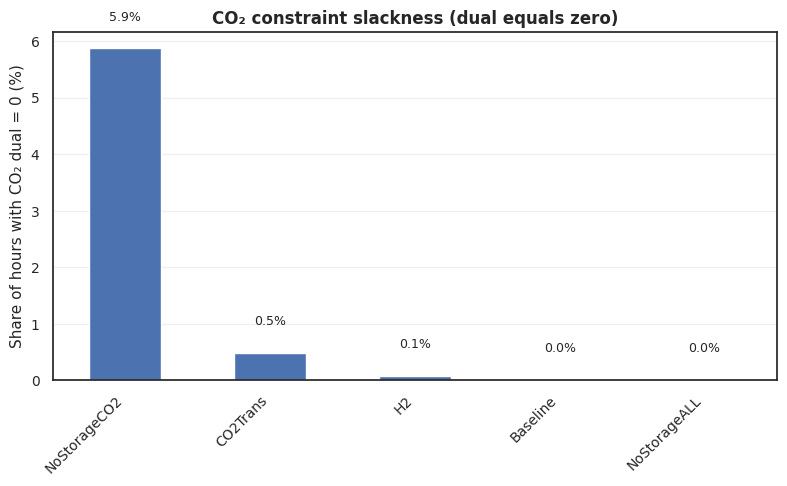

In [30]:
import matplotlib.pyplot as plt
import numpy as np

scenarios = [
    "Baseline",
    "NoStorageCO2",
    "NoStorageALL",
    "H2",
    "CO2Trans"
]

zero_share = (df[scenarios] == 0).mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(8,5))
zero_share.plot(kind="bar", ax=ax)

ax.set_ylabel("Share of hours with CO₂ dual = 0 (%)")
ax.set_title("CO₂ constraint slackness (dual equals zero)")
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

# value labels
for i, v in enumerate(zero_share.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("DualCO2_ZeroShare.pdf", bbox_inches="tight")
plt.show()


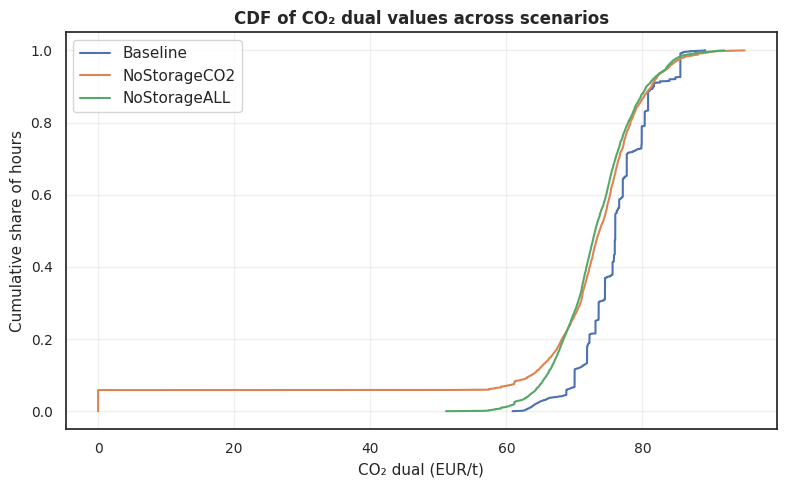

In [31]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8,5))

scenarios = [
    "Baseline",
    "NoStorageCO2",
    "NoStorageALL",
    # "H2",
    # "CO2Trans"
]

for s in scenarios:
    x = np.sort(df[s].dropna().values)
    y = np.arange(1, len(x) + 1) / len(x)
    ax.plot(x, y, label=s)

ax.set_xlabel("CO₂ dual (EUR/t)")
ax.set_ylabel("Cumulative share of hours")
ax.set_title("CDF of CO₂ dual values across scenarios")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig("DualCO2_CDF.pdf", bbox_inches="tight")
plt.show()


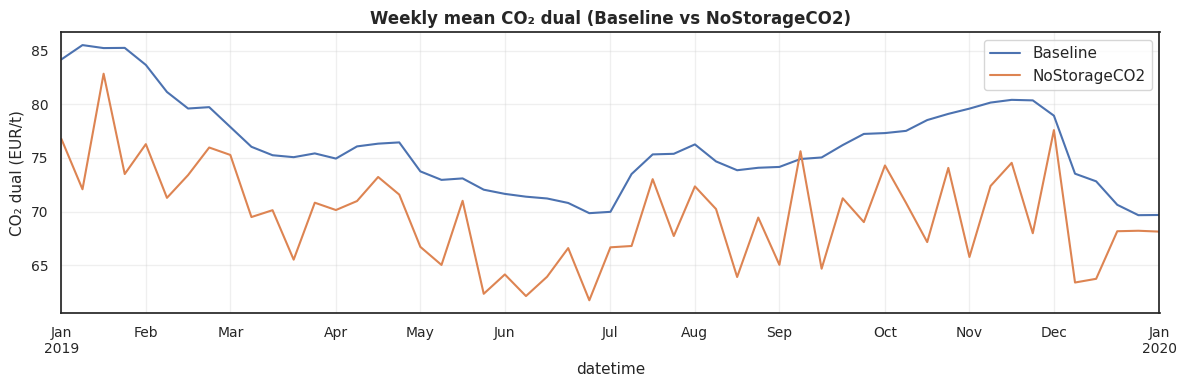

In [32]:
import matplotlib.pyplot as plt

# If df index is datetime, this will work nicely.
# If it's not datetime, it still plots but "weekly" won't be available.
s1, s2 = "Baseline", "NoStorageCO2"

fig, ax = plt.subplots(figsize=(12,4))

if np.issubdtype(df.index.dtype, np.datetime64):
    # weekly mean
    df[[s1, s2]].resample("W").mean().plot(ax=ax)
    ax.set_title("Weekly mean CO₂ dual (Baseline vs NoStorageCO2)")
else:
    # fallback: rolling mean over 168 hours (1 week)
    df[[s1, s2]].rolling(168, min_periods=1).mean().plot(ax=ax)
    ax.set_title("Rolling (168h) mean CO₂ dual (Baseline vs NoStorageCO2)")

ax.set_ylabel("CO₂ dual (EUR/t)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig("DualCO2_Time_Weekly.pdf", bbox_inches="tight")
plt.show()


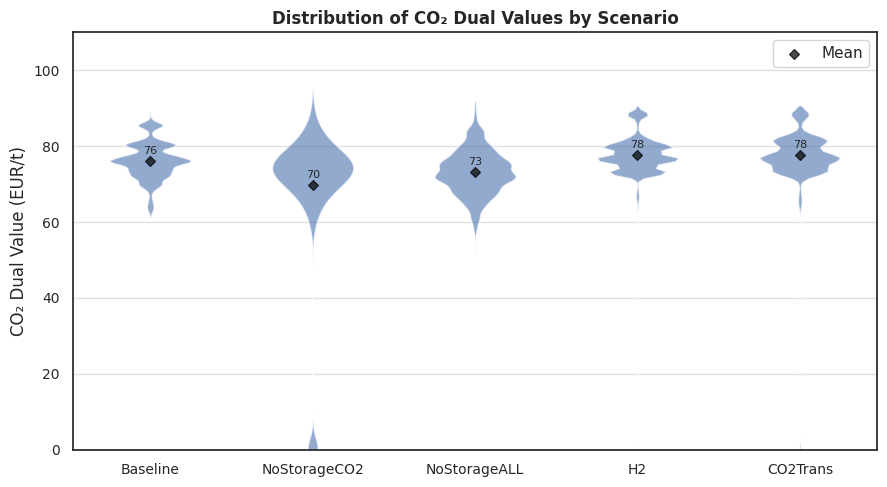

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# --- Select scenarios ---
scenarios = [
    "Baseline",
    "NoStorageCO2",
    "NoStorageALL",
    "H2",
    # "BioFixed",
    "CO2Trans"
]

fig, ax = plt.subplots(figsize=(9,5))

# --- Prepare data ---
data = [df[s].dropna().values for s in scenarios]

# --- Violin plot ---
vp = ax.violinplot(
    data,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

# Make violins cleaner
for body in vp["bodies"]:
    body.set_alpha(0.6)

# --- Compute means ---
means = df[scenarios].mean()
x_positions = np.arange(1, len(means) + 1)

# --- Mean markers (same style as your boxplots) ---
ax.scatter(
    x_positions,
    means,
    marker="D",
    s=25,
    color="black",
    alpha=0.7,
    label="Mean",
    zorder=3
)

# --- Mean value labels ---
for x, mean in zip(x_positions, means):
    ax.annotate(
        f"{mean:.0f}",
        (x, mean),
        textcoords="offset points",
        xytext=(0, 5),
        ha="center",
        fontsize=8
    )

# --- Axis formatting ---
ax.set_xticks(x_positions)
ax.set_xticklabels(scenarios)

ax.set_ylabel("CO₂ Dual Value (EUR/t)", fontsize=12)
ax.set_title("Distribution of CO₂ Dual Values by Scenario")
ax.set_ylim(0,110)

ax.grid(axis="y", alpha=0.6)
ax.set_axisbelow(True)

ax.legend()

plt.tight_layout()
plt.savefig("DualCO2_Violin.pdf", bbox_inches="tight")
plt.show()


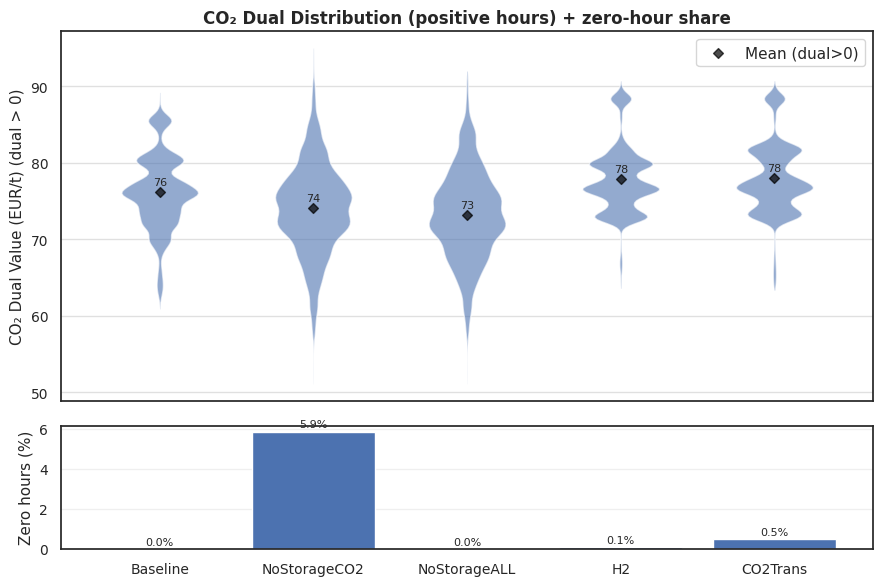

In [34]:
import matplotlib.pyplot as plt
import numpy as np

scenarios = ["Baseline", "NoStorageCO2", "NoStorageALL", "H2", "CO2Trans"]

# data
data_all = [df[s].dropna().values for s in scenarios]
data_pos = [df[s].dropna().values[df[s].dropna().values > 0] for s in scenarios]
zero_share = np.array([(np.array(v) == 0).mean() * 100 for v in data_all])

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(9, 6),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True
)

# --- Violin for positive values only ---
vp = ax1.violinplot(data_pos, showmeans=False, showmedians=False, showextrema=False)
for b in vp["bodies"]:
    b.set_alpha(0.6)

means_pos = np.array([np.mean(v) if len(v) else np.nan for v in data_pos])
x = np.arange(1, len(scenarios) + 1)

ax1.scatter(x, means_pos, marker="D", s=25, color="black", alpha=0.7, label="Mean (dual>0)", zorder=3)

for xi, m in zip(x, means_pos):
    if np.isfinite(m):
        ax1.annotate(f"{m:.0f}", (xi, m), textcoords="offset points", xytext=(0, 5),
                     ha="center", fontsize=8)

ax1.set_ylabel("CO₂ Dual Value (EUR/t) (dual > 0)")
ax1.set_title("CO₂ Dual Distribution (positive hours) + zero-hour share")
ax1.grid(axis="y", alpha=0.6)
ax1.set_axisbelow(True)
ax1.legend()

# --- Zero share bar (mechanism) ---
ax2.bar(x, zero_share)
ax2.set_ylabel("Zero hours (%)")
ax2.grid(axis="y", alpha=0.3)
ax2.set_axisbelow(True)

for xi, z in zip(x, zero_share):
    ax2.annotate(f"{z:.1f}%", (xi, z), textcoords="offset points", xytext=(0, 3),
                 ha="center", fontsize=8)

ax2.set_xticks(x)
ax2.set_xticklabels(scenarios)

plt.tight_layout()
plt.savefig("DualCO2_Violin_PositivePlusZeroShare.pdf", bbox_inches="tight")
plt.show()


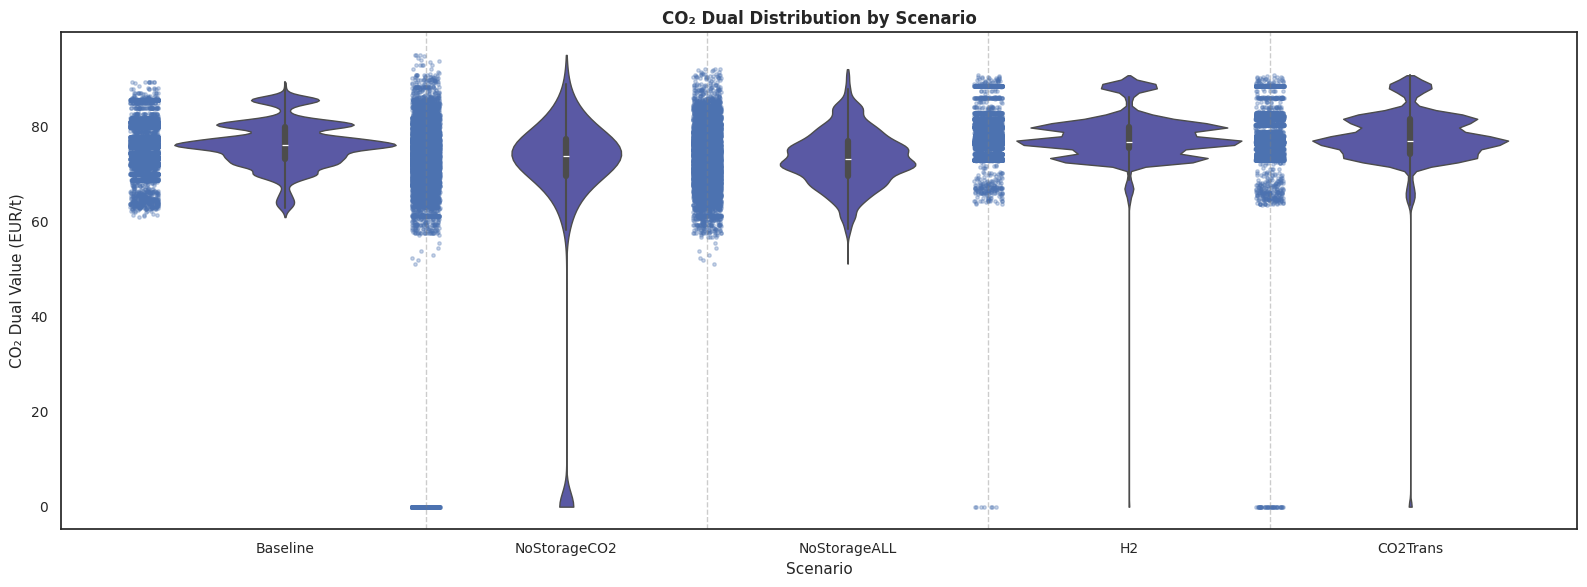

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

scenarios = ["Baseline", "NoStorageCO2", "NoStorageALL", "H2", "CO2Trans"]

# convert to long format
df_long = df[scenarios].melt(
    var_name="Scenario",
    value_name="CO2_dual"
)

fig, ax = plt.subplots(figsize=(16,6))

# --- violin ---
sns.violinplot(
    data=df_long,
    x="Scenario",
    y="CO2_dual",
    inner="box",
    cut=0,
    linewidth=1,
    color="#4e4cb0",
    ax=ax
)

# --- manually shift points LEFT of violin ---
x_positions = {s:i for i,s in enumerate(scenarios)}

x_jittered = [
    x_positions[s] - 0.5 + np.random.uniform(-0.05, 0.05)
    for s in df_long["Scenario"]
]

ax.scatter(
    x_jittered,
    df_long["CO2_dual"],
    s=6,
    alpha=0.3,
    color="#4c72b0"
)

# --- Add vertical separator lines between scenarios ---
for i in range(len(scenarios) - 1):
    ax.axvline(x=i + 0.5, color="gray", linestyle="--", linewidth=1, alpha=0.4)

ax.set_ylabel("CO₂ Dual Value (EUR/t)")
ax.set_title("CO₂ Dual Distribution by Scenario")

plt.tight_layout()
plt.savefig("DualCO2_ViolinPoints_Left.pdf")
plt.show()


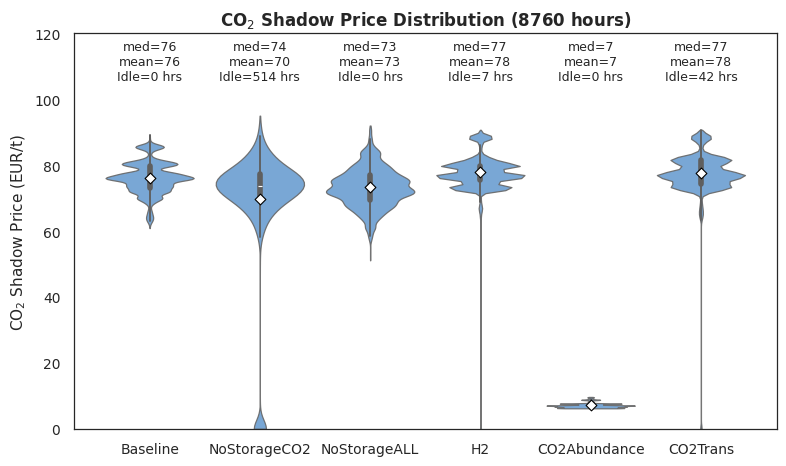

In [36]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection

scenarios = ["Baseline","NoStorageCO2","NoStorageALL","H2","CO2Abundance","CO2Trans"]

df_long = df[scenarios].melt(var_name="Scenario", value_name="CO2_price").dropna()

idle_eps = 1e-9
idle_hours = (df_long.assign(is_idle=lambda d: d["CO2_price"].abs() <= idle_eps)
                    .groupby("Scenario")["is_idle"].sum()
                    .reindex(scenarios).fillna(0).astype(int))

stats = (df_long.groupby("Scenario")["CO2_price"]
               .agg(med="median", mean="mean")
               .reindex(scenarios))

# ✅ Put typography into seaborn theme so it doesn't override you
sns.set_theme(
    style="white",
    rc={
        "font.family": "DejaVu Sans",
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.titleweight": "bold",   # match your reference look
        "text.usetex": False,         # keep mathtext consistent
    }
)

fig, ax = plt.subplots(figsize=(8, 4.8))

sns.violinplot(
    data=df_long, x="Scenario", y="CO2_price",
    order=scenarios,
    inner="box", cut=0,
    density_norm="width",
    bw_adjust=0.9,
    linewidth=0.9,
    color="#5A9EE2",
    ax=ax
)

for coll in ax.collections:
    if isinstance(coll, PolyCollection):
        coll.set_alpha(0.9)
        coll.set_edgecolor("#666666")
        coll.set_linewidth(0.9)

x_positions = np.arange(len(scenarios))
ax.scatter(
    x_positions, stats["mean"].values,
    marker="D", s=30,
    facecolor="white", edgecolor="black",
    linewidth=0.8, zorder=5
)

y_annot = 118
for i, scen in enumerate(scenarios):
    ax.text(
        i, y_annot,
        f"med={stats.loc[scen,'med']:.0f}\n"
        f"mean={stats.loc[scen,'mean']:.0f}\n"
        f"Idle={idle_hours.loc[scen]} hrs",
        ha="center", va="top", fontsize=9
    )

ax.set_title(r"CO$_2$ Shadow Price Distribution (8760 hours)")
ax.set_xlabel("")
ax.set_ylabel(r"CO$_2$ Shadow Price (EUR/t)")
ax.set_ylim(0, 120)
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.9)

plt.tight_layout()
plt.savefig("CO2_ShadowPrice_Violin.pdf", bbox_inches="tight", dpi=600)
plt.show()